# MTA Demand Model Comparison — MLP vs Blend vs LSTM (cấp GA)

So sánh ba kiến trúc dự báo **residual log-demand** tại **từng ga** (boarding/ga/giờ; baseline median theo `station×hour×weekend`) trên cùng hold-out mùa:

| Model | Mô tả |
|-------|--------|
| **MLP** | Mạng fully-connected với **station embedding** + BatchNorm; Huber loss trên residual. |
| **Blend** | Kết hợp MLP + HistGradientBoosting; trọng số blend và `RESID_CLIP` tune trên val (`summer_2025`). |
| **LSTM** | Chuỗi 24 giờ (theo **ga**) trên feature đã scale; 2-layer LSTM theo ITM 2026 MTA paper. |

Hold-out: **test = autumn_2025**, **val = summer_2025** (giống `mta-schedule-optimization.ipynb`).

Mặc định bật **`FAST_COMPARE`** (~4× nhanh hơn): huấn luyện trên 25% ngày train, ít epoch — đủ để xếp hạng MLP / Blend / LSTM, không dùng production.

Outputs: `outputs/model_comparison/` (Kaggle: `/kaggle/working/outputs/model_comparison`).


In [1]:
import os
import json
import time
import warnings
import random
import sys
import importlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# --- Cấu hình đường dẫn Kaggle Kernel (ưu tiên) + fallback local dev ---
KAGGLE_LIB_DIR = Path("/kaggle/input/datasets/tnguynthnh142/libmta")
KAGGLE_DATA_DIR = Path("/kaggle/input/datasets/tnguynthnh142/mta-subway-ny")
KAGGLE_SCHEDULE_DIR = Path("/kaggle/input/datasets/tnguynthnh142/schedule-subway")
KAGGLE_WORKING = Path("/kaggle/working")

ON_KAGGLE = KAGGLE_LIB_DIR.exists() or Path("/kaggle/input").exists()

if KAGGLE_LIB_DIR.exists():
    if str(KAGGLE_LIB_DIR) not in sys.path:
        sys.path.insert(0, str(KAGGLE_LIB_DIR))
    import single_route_pipeline as srp
    importlib.reload(srp)
    DATA_DIR = KAGGLE_DATA_DIR
    SCHEDULE_DIR = KAGGLE_SCHEDULE_DIR
    OUT_DIR = KAGGLE_WORKING / "outputs" / "model_comparison"
    NOTEBOOK_DIR = KAGGLE_WORKING
else:
    _cwd = Path(".").resolve()
    if (_cwd / "lib" / "single_route_pipeline.py").is_file():
        NOTEBOOK_DIR = _cwd
    elif (_cwd / "notebooks" / "lib" / "single_route_pipeline.py").is_file():
        NOTEBOOK_DIR = _cwd / "notebooks"
    else:
        raise ImportError(f"Cannot locate notebooks/lib from cwd={_cwd}")
    if str(NOTEBOOK_DIR) not in sys.path:
        sys.path.insert(0, str(NOTEBOOK_DIR))
    import lib.single_route_pipeline as srp
    importlib.reload(srp)
    REPO_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
    DATA_DIR = REPO_ROOT / "datasets"
    SCHEDULE_DIR = REPO_ROOT / "datasets" / "schedule_current"
    OUT_DIR = Path("outputs/model_comparison")

_required = ("prepare_lstm_sequences", "build_lstm_demand_model", "configure_gpu")
_missing = [name for name in _required if not hasattr(srp, name)]
if _missing:
    raise ImportError(
        f"single_route_pipeline thiếu: {_missing}. "
        f"Cập nhật notebooks/lib hoặc dataset libmta trên Kaggle."
    )

GPU_INFO = srp.configure_gpu(mixed_precision=True, memory_growth=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

MANIFEST_FILE = DATA_DIR / "train_manifest.json"
if MANIFEST_FILE.exists():
    with open(MANIFEST_FILE, encoding="utf-8") as f:
        train_manifest = json.load(f)
else:
    train_manifest = {}

_DEFAULT_PATHS = {
    "ridership": "ridership.csv",
    "routes_by_station_complex": "routes_by_station_complex.csv",
    "factors_hourly": "factors_hourly.csv",
}

def data_path(key: str) -> Path:
    paths_cfg = train_manifest.get("paths", {}) or {}
    name = paths_cfg.get(key, _DEFAULT_PATHS.get(key, key))
    return DATA_DIR / name

RIDERSHIP_FILE = data_path("ridership")
ROUTES_BY_COMPLEX_FILE = data_path("routes_by_station_complex")
FACTORS_HOURLY_FILE = data_path("factors_hourly")
FACTORS_JOIN_KEYS = ["date", "hour"]

_scope = train_manifest.get("scope", {})
OPT_HOURS_FALLBACK = _scope.get("hours", list(range(24)))
OPT_HOURS = list(OPT_HOURS_FALLBACK)
USE_GTFS_OPERATING_HOURS = True
MIN_GTFS_TRIPS_PER_HOUR = 1
OPT_ROUTE_MODE = _scope.get("route_mode", "headway")
DIRECTIONS = _scope.get("directions", [0, 1])
ROUTE_ALIASES = train_manifest.get("route_aliases", {"SIR": "SI"})
HEADWAY_SERVICE = "Weekday"
CHUNK_ROWS = 1_000_000

HOLDOUT_TEST_SEASON = "autumn"
HOLDOUT_TEST_YEAR = 2025
HOLDOUT_VAL_SEASON = "summer"
HOLDOUT_VAL_YEAR = 2025

# Station-level demand forecasting (thực thể dự báo = GA)
USE_STATION_EMBEDDING = True
STATION_EMBEDDING_DIM = 12
MIN_STATION_DEMAND_ROWS = 50

USE_LAG_FEATURES = True
LAG_FEATURE_COLS = ["log_lag_24h", "log_lag_168h", "log_rolling_7d"]
PEAK_HOURS = (7, 8, 9, 17, 18, 19)

HOURLY_FACTOR_COLS = [
    "temperature_c", "apparent_temperature_c",
    "precipitation_mm", "rain_mm", "snowfall_cm",
    "windspeed_kmh", "windgusts_kmh",
    "is_rain", "is_snow", "is_severe_wind",
    "is_major_event_window",
]

# Chế độ so sánh nhanh (~4x): đủ ranking kiến trúc, không cần độ chính xác production
FAST_COMPARE = True

NN_HIDDEN = (64, 32)
NN_DROPOUT = 0.25
USE_BATCH_NORM = True
PEAK_SAMPLE_WEIGHT = 2.0
RESID_CLIP = (-0.4, 0.4)
RESID_CLIP_CANDIDATES = [0.35, 0.45, 0.55]

if FAST_COMPARE:
    TRAIN_DATE_FRAC = 0.25          # huấn luyện trên 25% ngày train (val/test giữ nguyên)
    NN_EPOCHS_MAIN = 50
    HISTGBM_MAX_ITER = 100
    NN_EARLY_PATIENCE = 8
    LSTM_EARLY_PATIENCE = 8
    TUNE_RESID_CLIP_ON_VAL = False
    RESID_CLIP = (-0.45, 0.45)
    LSTM_HIDDEN = 32
    LSTM_LAYERS = 1
else:
    TRAIN_DATE_FRAC = 1.0
    NN_EPOCHS_MAIN = 200
    HISTGBM_MAX_ITER = 400
    NN_EARLY_PATIENCE = 25
    LSTM_EARLY_PATIENCE = 20
    TUNE_RESID_CLIP_ON_VAL = True
    LSTM_HIDDEN = 64
    LSTM_LAYERS = 2

NN_BATCH_SIZE = 512 if GPU_INFO.get("gpus") else 32
LSTM_BATCH_SIZE = min(NN_BATCH_SIZE, 128) if GPU_INFO.get("gpus") else 64
if FAST_COMPARE and GPU_INFO.get("gpus"):
    NN_BATCH_SIZE = 1024
    LSTM_BATCH_SIZE = 256

LSTM_SEQ_LEN = 24
LSTM_EPOCHS = NN_EPOCHS_MAIN

print("TensorFlow:", tf.__version__)
print(f"Pipeline lib: {Path(srp.__file__).parent}")
print(f"Môi trường: {'Kaggle' if ON_KAGGLE else 'local'} | GPU: {GPU_INFO.get('gpus') or 'CPU'} "
      f"| mixed_precision={GPU_INFO.get('mixed_precision')} memory_growth={GPU_INFO.get('memory_growth')}")
print(f"FAST_COMPARE={FAST_COMPARE} | train_date_frac={TRAIN_DATE_FRAC} | epochs={NN_EPOCHS_MAIN} | "
      f"batch={NN_BATCH_SIZE} (LSTM={LSTM_BATCH_SIZE})")
print(f"Demand entity: station-level")
print("Data dir:", DATA_DIR.resolve())
print("Output dir:", OUT_DIR.resolve())
for label, p in [
    ("ridership", RIDERSHIP_FILE),
    ("routes_by_station_complex", ROUTES_BY_COMPLEX_FILE),
    ("factors_hourly", FACTORS_HOURLY_FILE),
    ("schedule", SCHEDULE_DIR),
]:
    print(f"  {label}: {'OK' if p.exists() else 'MISSING'} — {p.name if p.is_file() else p}")


2026-06-25 04:57:01.729994: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782363421.932519      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782363421.991318      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782363422.487238      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782363422.487278      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782363422.487281      22 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
Pipeline lib: /kaggle/input/datasets/tnguynthnh142/libmta
Môi trường: Kaggle | GPU: ['/physical_device:GPU:0', '/physical_device:GPU:1'] | mixed_precision=True memory_growth=True
FAST_COMPARE=True | train_date_frac=0.25 | epochs=50 | batch=1024 (LSTM=256)
Demand entity: station-level
Data dir: /kaggle/input/datasets/tnguynthnh142/mta-subway-ny
Output dir: /kaggle/working/outputs/model_comparison
  ridership: OK — ridership.csv
  routes_by_station_complex: OK — routes_by_station_complex.csv
  factors_hourly: OK — factors_hourly.csv
  schedule: OK — /kaggle/input/datasets/tnguynthnh142/schedule-subway


## Load & merge data


In [2]:
# Station -> route map
routes_complex = pd.read_csv(ROUTES_BY_COMPLEX_FILE)
routes_complex["station_complex_id"] = routes_complex["station_complex_id"].astype(str)
route_col = "gtfs_route_ids" if "gtfs_route_ids" in routes_complex.columns else "route_ids_gtfs"
station_to_routes = (
    routes_complex.assign(route=routes_complex[route_col].astype(str).str.split())
    .explode("route")
    .dropna(subset=["route"])
)
station_to_routes = station_to_routes[station_to_routes["route"] != ""]
station_to_routes = station_to_routes[["station_complex_id", "route"]].drop_duplicates()
station_to_routes["route"] = station_to_routes["route"].replace(ROUTE_ALIASES)
valid_stations = set(station_to_routes["station_complex_id"].unique())

# Ridership chunked load — boarding tại GA
usecols = ["transit_timestamp", "transit_mode", "station_complex_id", "ridership"]
agg_parts = []
for chunk in pd.read_csv(
    RIDERSHIP_FILE,
    usecols=usecols,
    chunksize=CHUNK_ROWS,
    parse_dates=["transit_timestamp"],
    dtype={"station_complex_id": str},
):
    chunk = chunk[chunk["transit_mode"] == "subway"]
    chunk = chunk[chunk["station_complex_id"].isin(valid_stations)]
    if chunk.empty:
        continue
    chunk["date"] = chunk["transit_timestamp"].dt.date
    chunk["hour"] = chunk["transit_timestamp"].dt.hour
    grp = chunk.groupby(["station_complex_id", "date", "hour"], as_index=False)["ridership"].sum()
    agg_parts.append(grp)

ridership_station = pd.concat(agg_parts, ignore_index=True)
ridership_station = (
    ridership_station.groupby(["station_complex_id", "date", "hour"], as_index=False)["ridership"]
    .sum()
    .rename(columns={"ridership": "demand"})
)

# GTFS — scope tuyến & trọng số ga×route (lọc OPT_STATIONS)
headway = srp.build_headway_from_gtfs(SCHEDULE_DIR, service_id=HEADWAY_SERVICE)
headway["route_id"] = headway["route_id"].astype(str)
station_rd_weights = srp.build_station_route_direction_weights(
    station_to_routes, headway,
    min_trips=MIN_GTFS_TRIPS_PER_HOUR, route_aliases=ROUTE_ALIASES,
)

def load_factors_hourly(path: Path) -> pd.DataFrame:
    fh = pd.read_csv(path, parse_dates=["timestamp", "date"])
    if "hour" not in fh.columns:
        fh["hour"] = fh["timestamp"].dt.hour
    keep = [
        "date", "hour", "day_of_week", "is_weekend", "is_us_holiday", "month",
        "temperature_c", "apparent_temperature_c",
        "precipitation_mm", "rain_mm", "snowfall_cm",
        "windspeed_kmh", "windgusts_kmh",
        "is_rain", "is_snow", "is_severe_wind",
        "is_major_event_window",
    ]
    keep = [c for c in keep if c in fh.columns]
    fh = fh[keep].drop_duplicates(subset=["date", "hour"]).copy()
    fh["date"] = pd.to_datetime(fh["date"]).dt.normalize()
    fh["hour"] = fh["hour"].astype(int)
    return fh

factors = load_factors_hourly(FACTORS_HOURLY_FILE)

ridership_station["date"] = pd.to_datetime(ridership_station["date"]).dt.normalize()
ridership_station["hour"] = ridership_station["hour"].astype(int)
ridership_all = ridership_station.merge(factors, on=FACTORS_JOIN_KEYS, how="left")

if "day_of_week" in ridership_all.columns:
    ridership_all["day_of_week"] = ridership_all["day_of_week"].fillna(ridership_all["date"].dt.dayofweek)
else:
    ridership_all["day_of_week"] = ridership_all["date"].dt.dayofweek
if "is_weekend" in ridership_all.columns:
    ridership_all["is_weekend"] = ridership_all["is_weekend"].fillna((ridership_all["date"].dt.dayofweek >= 5).astype(int))
else:
    ridership_all["is_weekend"] = (ridership_all["date"].dt.dayofweek >= 5).astype(int)

flag_cols = [
    "is_us_holiday", "is_rain", "is_snow", "is_severe_wind",
    "is_major_event_window",
]
num_cols = [c for c in HOURLY_FACTOR_COLS if c not in flag_cols]
for c in num_cols:
    if c not in ridership_all.columns:
        ridership_all[c] = 0.0
    ridership_all[c] = ridership_all[c].fillna(ridership_all[c].median())
for c in flag_cols:
    if c not in ridership_all.columns:
        ridership_all[c] = 0
    ridership_all[c] = ridership_all[c].fillna(0).astype(int)

# OPT_ROUTES (scope tối ưu) → OPT_STATIONS (ga huấn luyện)
HEADWAY_ROUTES = sorted(headway["route_id"].astype(str).unique())
active_stations = set(ridership_all["station_complex_id"].astype(str).unique())
_route_station_cnt = (
    station_rd_weights[station_rd_weights["station_complex_id"].isin(active_stations)]
    .groupby("route")["station_complex_id"].nunique()
)
RIDERSHIP_ROUTES = _route_station_cnt[_route_station_cnt >= 1].index.astype(str).tolist()

if OPT_ROUTE_MODE == "headway":
    OPT_ROUTES = HEADWAY_ROUTES
elif OPT_ROUTE_MODE == "intersection":
    OPT_ROUTES = sorted(set(HEADWAY_ROUTES) & set(RIDERSHIP_ROUTES))
else:
    OPT_ROUTES = RIDERSHIP_ROUTES
OPT_ROUTES = [r for r in OPT_ROUTES if r in set(RIDERSHIP_ROUTES)]

route_hours = {r: list(OPT_HOURS_FALLBACK) for r in OPT_ROUTES}
route_dir_hours: dict[tuple[str, int], list[int]] = {}
if USE_GTFS_OPERATING_HOURS:
    route_dir_hours = srp.derive_operating_hours_by_route_direction(
        headway, OPT_ROUTES, directions=DIRECTIONS, min_trips=MIN_GTFS_TRIPS_PER_HOUR
    )
    route_hours = srp.derive_operating_hours_by_route(
        headway, OPT_ROUTES, directions=DIRECTIONS, min_trips=MIN_GTFS_TRIPS_PER_HOUR
    )
    OPT_HOURS = sorted({h for hs in route_dir_hours.values() for h in hs})

scope_stations = set(
    station_rd_weights.loc[station_rd_weights["route"].isin(OPT_ROUTES), "station_complex_id"]
) & active_stations
station_row_counts = ridership_all.groupby("station_complex_id").size()
OPT_STATIONS = sorted(
    s for s in scope_stations if int(station_row_counts.get(s, 0)) >= MIN_STATION_DEMAND_ROWS
)

df = ridership_all[ridership_all["station_complex_id"].isin(OPT_STATIONS)].copy()

print(f"OPT_ROUTES ({len(OPT_ROUTES)}): {OPT_ROUTES[:8]} ...")
print(f"OPT_STATIONS: {len(OPT_STATIONS)} ga")
print(f"Dataset NN (station-level): {len(df):,} rows | {df['date'].nunique()} days | "
      f"demand {df['demand'].min():.0f}–{df['demand'].max():.0f}")


OPT_ROUTES (25): ['1', '2', '3', '4', '5', '6', '7', 'A'] ...
OPT_STATIONS: 424 ga
Dataset NN (station-level): 7,275,945 rows | 731 days | demand 1–23060


## Feature engineering & splits


In [3]:
df = df.sort_values(["station_complex_id", "date", "hour"]).reset_index(drop=True)
if "month" not in df.columns:
    df["month"] = df["date"].dt.month

df = srp.add_cyclical_time_features(df)

# Thực thể embedding = GA; input Keras vẫn tên route_idx (tương thích artifact)
station_to_idx = {s: i for i, s in enumerate(OPT_STATIONS)}
df["station_idx"] = df["station_complex_id"].map(station_to_idx).astype(int)
df["route_idx"] = df["station_idx"]
route_to_idx = station_to_idx

df = srp.add_lag_features(
    df, use_lags=USE_LAG_FEATURES, lag_cols=LAG_FEATURE_COLS, entity_col="station_complex_id"
)

unique_dates = sorted(df["date"].unique())
train_dates, val_dates, test_dates, holdout_meta = srp.build_seasonal_holdout_splits(
    unique_dates,
    test_season=HOLDOUT_TEST_SEASON,
    test_season_year=HOLDOUT_TEST_YEAR,
    val_season=HOLDOUT_VAL_SEASON,
    val_season_year=HOLDOUT_VAL_YEAR,
    auto_adjust=False,
    return_meta=True,
)
HOLDOUT_TEST_SEASON = holdout_meta["test_season"]
HOLDOUT_TEST_YEAR = holdout_meta["test_season_year"]
HOLDOUT_VAL_SEASON = holdout_meta["val_season"]
HOLDOUT_VAL_YEAR = holdout_meta["val_season_year"]

train_df = df[df["date"].isin(train_dates)].copy()
val_df = df[df["date"].isin(val_dates)].copy()
test_df = df[df["date"].isin(test_dates)].copy()

# Baseline luôn tính trên toàn bộ train; fit có thể subsample ngày (FAST_COMPARE)
baseline_lookup = (
    train_df.groupby(["station_complex_id", "hour", "is_weekend"])["demand"].median().rename("baseline_demand")
)
fallback = train_df.groupby(["station_complex_id", "hour"])["demand"].median().rename("fallback_demand")

def attach_baseline(d: pd.DataFrame) -> pd.DataFrame:
    d = d.merge(baseline_lookup, on=["station_complex_id", "hour", "is_weekend"], how="left")
    d = d.merge(fallback, on=["station_complex_id", "hour"], how="left")
    d["baseline_demand"] = d["baseline_demand"].fillna(d["fallback_demand"])
    return d.drop(columns=["fallback_demand"])

train_df = attach_baseline(train_df)
val_df = attach_baseline(val_df)
test_df = attach_baseline(test_df)

train_df = srp.fill_lag_from_train(train_df, train_df, lag_cols=LAG_FEATURE_COLS, entity_col="station_complex_id")
val_df = srp.fill_lag_from_train(val_df, train_df, lag_cols=LAG_FEATURE_COLS, entity_col="station_complex_id")
test_df = srp.fill_lag_from_train(test_df, train_df, lag_cols=LAG_FEATURE_COLS, entity_col="station_complex_id")

for part in (train_df, val_df, test_df):
    part["log_baseline"] = np.log1p(part["baseline_demand"])
    part["residual_log_demand"] = np.log1p(part["demand"]) - part["log_baseline"]

fit_train_dates = set(train_dates)
if TRAIN_DATE_FRAC < 1.0:
    _n_fit = max(14, int(len(train_dates) * TRAIN_DATE_FRAC))
    fit_train_dates = set(
        pd.Series(sorted(train_dates)).sample(n=_n_fit, random_state=SEED).tolist()
    )
    print(f"FAST_COMPARE: fit trên {_n_fit}/{len(train_dates)} ngày train "
          f"({len(train_df[train_df['date'].isin(fit_train_dates)]):,} hàng)")

train_fit_df = train_df[train_df["date"].isin(fit_train_dates)].copy()

NUM_FEATURES = srp.build_num_feature_list(
    HOURLY_FACTOR_COLS,
    use_lags=USE_LAG_FEATURES,
    lag_cols=LAG_FEATURE_COLS,
)
NUM_FEATURES = [c for c in NUM_FEATURES if c in train_df.columns]

y_train = train_fit_df["residual_log_demand"].values
y_val = val_df["residual_log_demand"].values
y_test = test_df["residual_log_demand"].values

scaler = StandardScaler()
X_train_num = scaler.fit_transform(train_fit_df[NUM_FEATURES])
X_val_num = scaler.transform(val_df[NUM_FEATURES])
X_test_num = scaler.transform(test_df[NUM_FEATURES])
X_train_route = train_fit_df["route_idx"].values.reshape(-1, 1)
X_val_route = val_df["route_idx"].values.reshape(-1, 1)
X_test_route = test_df["route_idx"].values.reshape(-1, 1)

print(f"NUM_FEATURES ({len(NUM_FEATURES)}): {NUM_FEATURES}")
print(f"Hold-out: test={HOLDOUT_TEST_SEASON}_{HOLDOUT_TEST_YEAR}, val={HOLDOUT_VAL_SEASON}_{HOLDOUT_VAL_YEAR}")
print(f"Train fit {len(train_fit_df):,} | Val {len(val_df):,} | Test {len(test_df):,}")
print(f"Target residual — train mean={y_train.mean():.3f}, std={y_train.std():.3f}")


FAST_COMPARE: fit trên 137/548 ngày train (1,360,684 hàng)
NUM_FEATURES (23): ['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'is_weekend', 'is_us_holiday', 'temperature_c', 'apparent_temperature_c', 'precipitation_mm', 'rain_mm', 'snowfall_cm', 'windspeed_kmh', 'windgusts_kmh', 'is_rain', 'is_snow', 'is_severe_wind', 'is_major_event_window', 'log_baseline', 'log_lag_24h', 'log_lag_168h', 'log_rolling_7d']
Hold-out: test=autumn_2025, val=summer_2025
Train fit 1,360,684 | Val 921,316 | Test 910,409
Target residual — train mean=-0.042, std=0.396


## MLP training


In [4]:
def _fit_inputs(route_idx, num_feat):
    return srp.format_keras_inputs(route_idx, num_feat, use_route_embedding=USE_STATION_EMBEDDING)

mlp_model = srp.build_demand_model(
    len(station_to_idx),
    len(NUM_FEATURES),
    use_route_embedding=USE_STATION_EMBEDDING,
    embedding_dim=STATION_EMBEDDING_DIM,
    hidden=NN_HIDDEN,
    dropout=NN_DROPOUT,
    use_batch_norm=USE_BATCH_NORM,
)
mlp_model.summary()

train_weights = np.ones(len(train_fit_df), dtype=float)
peak_mask = train_fit_df["hour"].isin(PEAK_HOURS)
train_weights[peak_mask.to_numpy()] = PEAK_SAMPLE_WEIGHT
print(f"Peak sample weight x{PEAK_SAMPLE_WEIGHT}: {peak_mask.sum():,}/{len(train_fit_df):,}")

early = EarlyStopping(monitor="val_loss", patience=NN_EARLY_PATIENCE, restore_best_weights=True)
t0 = time.perf_counter()
mlp_history = mlp_model.fit(
    _fit_inputs(X_train_route, X_train_num),
    y_train,
    validation_data=(_fit_inputs(X_val_route, X_val_num), y_val),
    sample_weight=train_weights,
    epochs=NN_EPOCHS_MAIN,
    batch_size=NN_BATCH_SIZE,
    verbose=0,
    callbacks=[early],
)
mlp_train_sec = time.perf_counter() - t0
mlp_n_params = int(mlp_model.count_params())
print(f"MLP done @ epoch {len(mlp_history.history['loss'])} | {mlp_train_sec:.1f}s | params={mlp_n_params:,}")

def predict_resid_mlp(route_idx_arr, num_feat_arr):
    return mlp_model.predict(_fit_inputs(route_idx_arr, num_feat_arr), verbose=0).ravel()


I0000 00:00:1782363619.326322      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782363619.332338      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ route_idx           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ route_emb           │ (None, 1, 12)     │      5,088 │ route_idx[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 12)        │          0 │ route_emb[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ num_features        │ (None, 23)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 35)        │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ num_features[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_0 (Dense)     │ (None, 64)        │      2,304 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_0                │ (None, 64)        │        256 │ dense_0[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_0 (Dropout) │ (None, 64)        │          0 │ bn_0[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      2,080 │ dropout_0[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_1                │ (None, 32)        │        128 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32)        │          0 │ bn_1[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_log_demand │ (None, 1)         │         33 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 9,889 (38.63 KB)

 Trainable params: 9,697 (37.88 KB)

 Non-trainable params: 192 (768.00 B)

Peak sample weight x2.0: 342,397/1,360,684


I0000 00:00:1782363623.406958      69 service.cc:152] XLA service 0x7b7574038c60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782363623.406997      69 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1782363623.407001      69 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1782363623.906024      69 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1782363627.243245      69 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


MLP done @ epoch 19 | 113.6s | params=9,889


## Blend (MLP + HistGBM)


In [5]:
t0 = time.perf_counter()
histgbm_model = srp.fit_histgbm_demand(
    X_train_num, y_train, sample_weight=train_weights, max_iter=HISTGBM_MAX_ITER
)
blend_train_sec = time.perf_counter() - t0
blend_n_params = getattr(histgbm_model, "n_trees_", None) or len(getattr(histgbm_model, "train_score_", []))
print(f"HistGBM fitted in {blend_train_sec:.1f}s | trees/iter proxy={blend_n_params}")

if TUNE_RESID_CLIP_ON_VAL:
    best_clip, best_mae = RESID_CLIP[1], float("inf")
    for clip_hi in RESID_CLIP_CANDIDATES:
        tmp_clip = (-clip_hi, clip_hi)
        pred_resid = np.clip(predict_resid_mlp(X_val_route, X_val_num), *tmp_clip)
        pred_val = srp.residuals_to_demand(val_df["log_baseline"].values, pred_resid, tmp_clip)
        mae_val = mean_absolute_error(val_df["demand"].values, pred_val)
        print(f"  val MAE @ clip +/-{clip_hi:.2f}: {mae_val:,.1f}")
        if mae_val < best_mae:
            best_mae, best_clip = mae_val, clip_hi
    RESID_CLIP = (-best_clip, best_clip)
    print(f"-> RESID_CLIP = +/-{best_clip:.2f} (val MAE={best_mae:,.1f})")

pred_mlp_val = np.clip(predict_resid_mlp(X_val_route, X_val_num), *RESID_CLIP)
pred_gbm_val = histgbm_model.predict(X_val_num)
blend_weight, blend_val_mae = srp.tune_blend_weight_mae(
    pred_mlp_val,
    pred_gbm_val,
    val_df["log_baseline"].values,
    val_df["demand"].values,
    RESID_CLIP,
)
print(f"Blend weight (MLP)={blend_weight:.2f} | val MAE={blend_val_mae:,.1f}")

def predict_demand_blend(route_idx_arr, num_feat_arr, log_baseline):
    pred_mlp = np.clip(predict_resid_mlp(route_idx_arr, num_feat_arr), *RESID_CLIP)
    pred_gbm = histgbm_model.predict(num_feat_arr)
    pred_resid = srp.blend_residual_predictions(pred_mlp, pred_gbm, blend_weight)
    return srp.residuals_to_demand(log_baseline, pred_resid, RESID_CLIP)



HistGBM fitted in 12.1s | trees/iter proxy=101
Blend weight (MLP)=1.00 | val MAE=41.4


## LSTM training


In [6]:
def attach_scaled_features(d: pd.DataFrame, scaler_obj, feature_cols: list[str], prefix: str = "scaled_") -> pd.DataFrame:
    out = d.copy()
    arr = scaler_obj.transform(out[feature_cols].values)
    for i, col in enumerate(feature_cols):
        out[f"{prefix}{col}"] = arr[:, i]
    return out

lstm_df = pd.concat([train_df, val_df, test_df], ignore_index=True)
if TRAIN_DATE_FRAC < 1.0:
    lstm_df = pd.concat(
        [train_df[train_df["date"].isin(fit_train_dates)], val_df, test_df],
        ignore_index=True,
    )
lstm_df = attach_scaled_features(lstm_df, scaler, NUM_FEATURES)
LSTM_FEATURE_COLS = [f"scaled_{c}" for c in NUM_FEATURES]

train_date_set = fit_train_dates
val_date_set = val_dates
test_date_set = test_dates

X_lstm_train, y_lstm_train, meta_lstm_train, stats_train = srp.prepare_lstm_sequences(
    lstm_df,
    LSTM_SEQ_LEN,
    LSTM_FEATURE_COLS,
    "residual_log_demand",
    train_dates=train_date_set,
    val_dates=val_date_set,
    test_dates=test_date_set,
    target_split="train",
    route_col="station_complex_id",
)
X_lstm_val, y_lstm_val, meta_lstm_val, stats_val = srp.prepare_lstm_sequences(
    lstm_df,
    LSTM_SEQ_LEN,
    LSTM_FEATURE_COLS,
    "residual_log_demand",
    train_dates=train_date_set,
    val_dates=val_date_set,
    test_dates=test_date_set,
    target_split="val",
    route_col="station_complex_id",
)
X_lstm_test, y_lstm_test, meta_lstm_test, stats_test = srp.prepare_lstm_sequences(
    lstm_df,
    LSTM_SEQ_LEN,
    LSTM_FEATURE_COLS,
    "residual_log_demand",
    train_dates=train_date_set,
    val_dates=val_date_set,
    test_dates=test_date_set,
    target_split="test",
    meta_cols=["station_complex_id", "date", "hour", "log_baseline", "demand"],
    route_col="station_complex_id",
)
print("LSTM sequences:", stats_train, stats_val, stats_test)

lstm_model = srp.build_lstm_demand_model(
    LSTM_SEQ_LEN,
    len(LSTM_FEATURE_COLS),
    hidden_units=LSTM_HIDDEN,
    num_lstm_layers=LSTM_LAYERS,
    dropout=NN_DROPOUT,
    use_batch_norm=USE_BATCH_NORM,
)
lstm_model.summary()

lstm_train_keys = meta_lstm_train.merge(
    train_fit_df.assign(_w=train_weights)[["station_complex_id", "date", "hour", "_w"]],
    on=["station_complex_id", "date", "hour"],
    how="left",
)
lstm_sample_weight = lstm_train_keys["_w"].fillna(1.0).values

lstm_early = EarlyStopping(monitor="val_loss", patience=LSTM_EARLY_PATIENCE, restore_best_weights=True)
t0 = time.perf_counter()
lstm_history = lstm_model.fit(
    X_lstm_train,
    y_lstm_train,
    validation_data=(X_lstm_val, y_lstm_val),
    sample_weight=lstm_sample_weight,
    epochs=LSTM_EPOCHS,
    batch_size=LSTM_BATCH_SIZE,
    verbose=0,
    callbacks=[lstm_early],
)
lstm_train_sec = time.perf_counter() - t0
lstm_n_params = int(lstm_model.count_params())
print(f"LSTM done @ epoch {len(lstm_history.history['loss'])} | {lstm_train_sec:.1f}s | params={lstm_n_params:,}")


LSTM sequences: {'split': 'train', 'n_samples': 1350508, 'seq_len': 24, 'n_features': 23, 'n_routes': 424, 'skipped_short_history': 0, 'skipped_nan': 0, 'skipped_wrong_split': 1831725} {'split': 'val', 'n_samples': 921316, 'seq_len': 24, 'n_features': 23, 'n_routes': 424, 'skipped_short_history': 0, 'skipped_nan': 0, 'skipped_wrong_split': 2260917} {'split': 'test', 'n_samples': 910409, 'seq_len': 24, 'n_features': 23, 'n_routes': 424, 'skipped_short_history': 0, 'skipped_nan': 0, 'skipped_wrong_split': 2271824}


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_sequence (InputLayer)      │ (None, 24, 23)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_0 (LSTM)                   │ (None, 32)             │         7,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_lstm (BatchNormalization)    │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_head (Dense)              │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_head (Dropout)          │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_log_demand (Dense)     │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,841 (30.63 KB)

 Trainable params: 7,777 (30.38 KB)

 Non-trainable params: 64 (256.00 B)

LSTM done @ epoch 43 | 2153.0s | params=7,841


## Evaluation


In [7]:
# Align LSTM test rows with tabular test set on station+date+hour
meta_lstm_test = meta_lstm_test.copy()
meta_lstm_test["date"] = pd.to_datetime(meta_lstm_test["date"]).dt.normalize()
meta_lstm_test["_lstm_idx"] = np.arange(len(meta_lstm_test))

test_keys = test_df[["station_complex_id", "date", "hour"]].copy()
test_keys["date"] = pd.to_datetime(test_keys["date"]).dt.normalize()
test_keys["row_idx"] = np.arange(len(test_df))

aligned = meta_lstm_test.merge(test_keys, on=["station_complex_id", "date", "hour"], how="inner")
print(f"LSTM test samples aligned with tabular test: {len(aligned):,} / {len(meta_lstm_test):,}")

idx = aligned["row_idx"].values
y_true_aligned = test_df.iloc[idx]["demand"].values
log_base_aligned = test_df.iloc[idx]["log_baseline"].values
baseline_aligned = test_df.iloc[idx]["baseline_demand"].values

pred_mlp_resid = np.clip(predict_resid_mlp(X_test_route[idx], X_test_num[idx]), *RESID_CLIP)
pred_mlp = srp.residuals_to_demand(log_base_aligned, pred_mlp_resid, RESID_CLIP)
pred_blend = predict_demand_blend(X_test_route[idx], X_test_num[idx], log_base_aligned)

lstm_pos = aligned["_lstm_idx"].values
pred_lstm_resid = np.clip(lstm_model.predict(X_lstm_test[lstm_pos], verbose=0).ravel(), *RESID_CLIP)
pred_lstm = srp.residuals_to_demand(log_base_aligned, pred_lstm_resid, RESID_CLIP)

m_base = srp.regression_metrics(y_true_aligned, baseline_aligned)
m_mlp = srp.regression_metrics(y_true_aligned, pred_mlp)
m_blend = srp.regression_metrics(y_true_aligned, pred_blend)
m_lstm = srp.regression_metrics(y_true_aligned, pred_lstm)

comparison_df = pd.DataFrame([
    {
        "model": "baseline",
        "mae": m_base["mae"],
        "rmse": m_base["rmse"],
        "r2": m_base["r2"],
        "mape_pct": m_base["mape_pct"],
        "smape_pct": m_base["smape_pct"],
        "train_sec": 0.0,
        "n_params": 0,
    },
    {
        "model": "mlp",
        "mae": m_mlp["mae"],
        "rmse": m_mlp["rmse"],
        "r2": m_mlp["r2"],
        "mape_pct": m_mlp["mape_pct"],
        "smape_pct": m_mlp["smape_pct"],
        "train_sec": mlp_train_sec,
        "n_params": mlp_n_params,
    },
    {
        "model": "blend",
        "mae": m_blend["mae"],
        "rmse": m_blend["rmse"],
        "r2": m_blend["r2"],
        "mape_pct": m_blend["mape_pct"],
        "smape_pct": m_blend["smape_pct"],
        "train_sec": mlp_train_sec + blend_train_sec,
        "n_params": mlp_n_params + int(blend_n_params),
    },
    {
        "model": "lstm",
        "mae": m_lstm["mae"],
        "rmse": m_lstm["rmse"],
        "r2": m_lstm["r2"],
        "mape_pct": m_lstm["mape_pct"],
        "smape_pct": m_lstm["smape_pct"],
        "train_sec": lstm_train_sec,
        "n_params": lstm_n_params,
    },
])
comparison_df.to_csv(OUT_DIR / "model_comparison.csv", index=False)
display(comparison_df.round(3))

eval_bundle = {
    "entity": "station",
    "n_stations": int(len(OPT_STATIONS)),
    "holdout_test": f"{HOLDOUT_TEST_SEASON}_{HOLDOUT_TEST_YEAR}",
    "holdout_val": f"{HOLDOUT_VAL_SEASON}_{HOLDOUT_VAL_YEAR}",
    "n_aligned_test": int(len(aligned)),
    "resid_clip": float(RESID_CLIP[1]),
    "blend_mlp_weight": float(blend_weight),
    "lstm_seq_len": LSTM_SEQ_LEN,
    "station_embedding_dim": int(STATION_EMBEDDING_DIM),
    "fast_compare": bool(FAST_COMPARE),
    "train_date_frac": float(TRAIN_DATE_FRAC),
    "metrics": {
        "baseline": m_base,
        "mlp": m_mlp,
        "blend": m_blend,
        "lstm": m_lstm,
    },
}
with open(OUT_DIR / "model_comparison.json", "w", encoding="utf-8") as f:
    json.dump(eval_bundle, f, indent=2)


LSTM test samples aligned with tabular test: 910,409 / 910,409


,model,mae,rmse,r2,mape_pct,smape_pct,train_sec,n_params
0,baseline,67.386,197.992,0.934,19.477,25.004,0.000,0
1,mlp,50.938,164.163,0.955,14.428,20.523,113.600,9889
2,blend,50.938,164.163,0.955,14.428,20.523,125.733,9990
3,lstm,57.668,182.158,0.944,16.619,22.407,2153.002,7841


## Plots


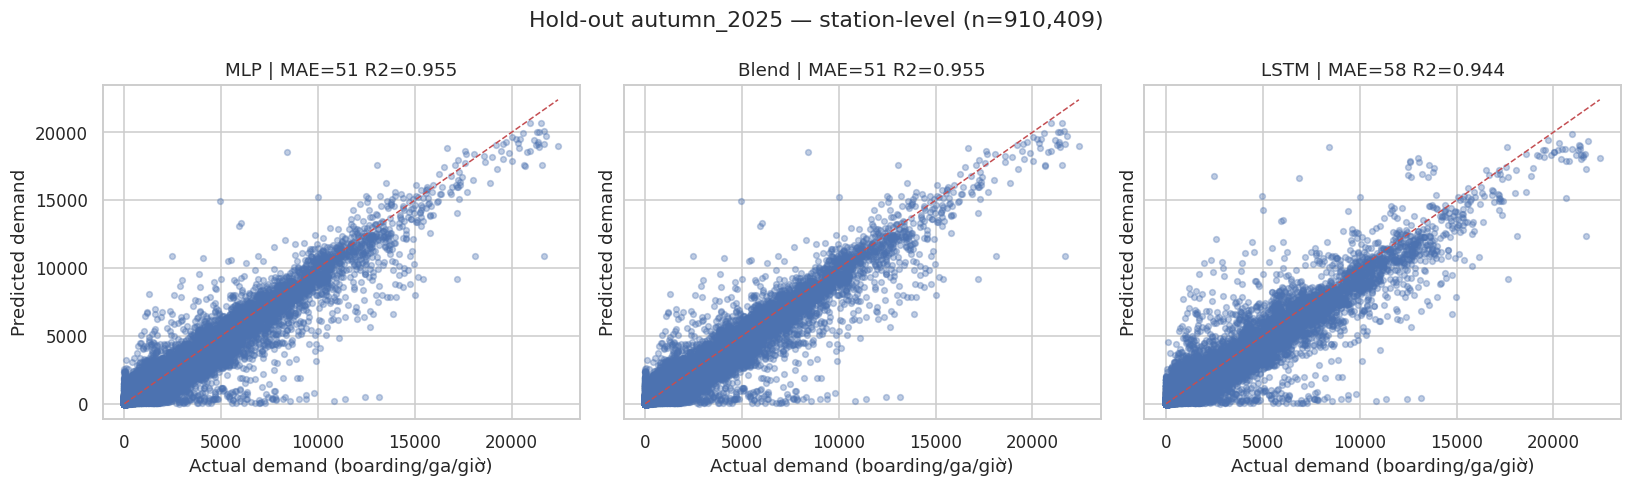

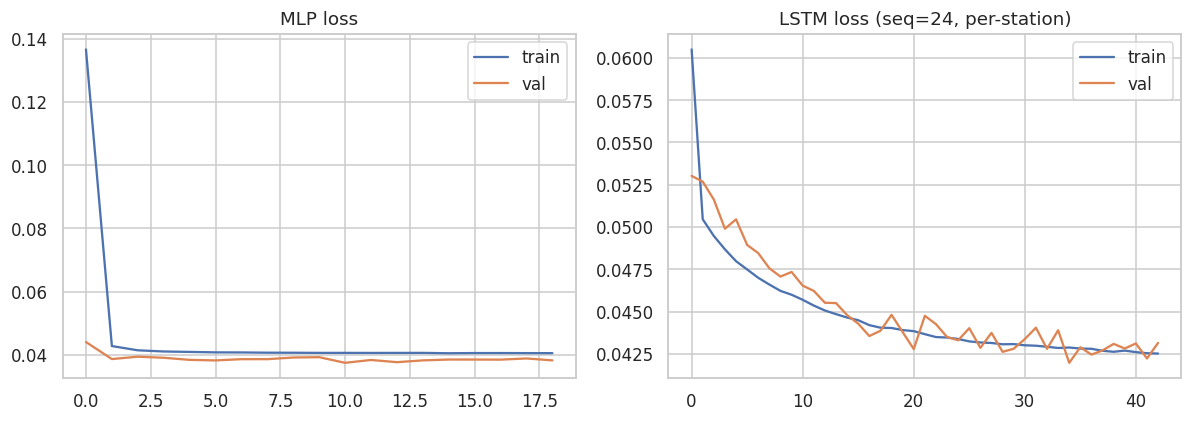

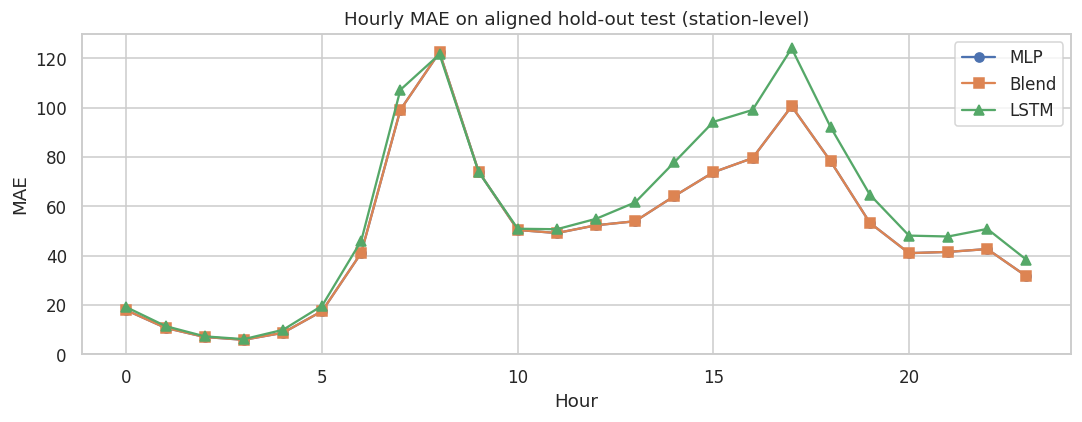

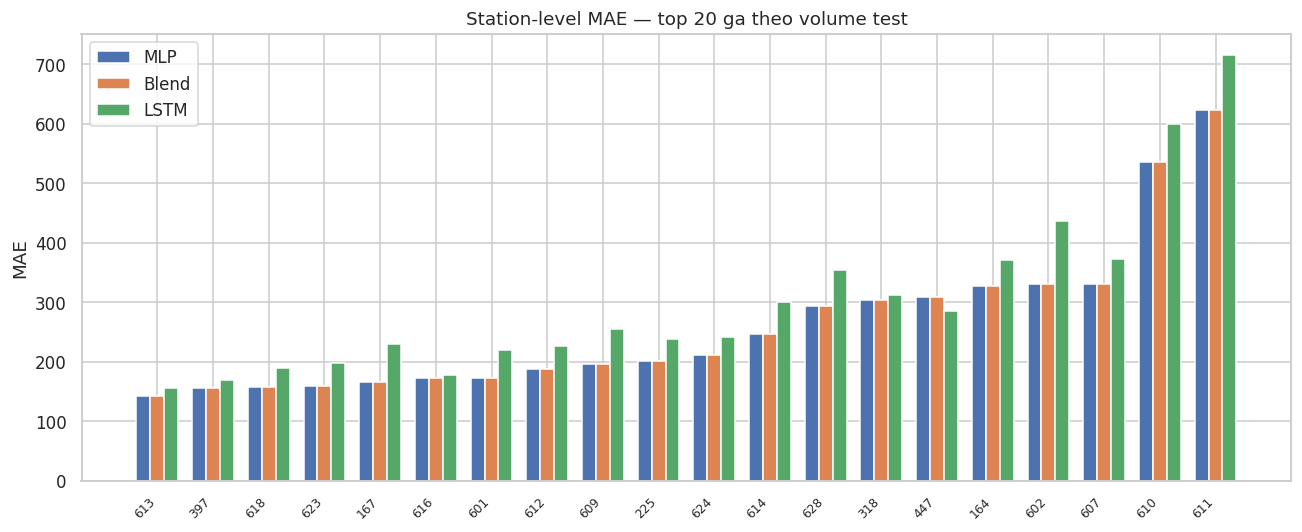

In [8]:
# Pred vs actual — 3 models
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True, sharey=True)
for ax, pred, name, m in zip(
    axes,
    [pred_mlp, pred_blend, pred_lstm],
    ["MLP", "Blend", "LSTM"],
    [m_mlp, m_blend, m_lstm],
):
    ax.scatter(y_true_aligned, pred, alpha=0.35, s=14)
    lim = max(y_true_aligned.max(), pred.max())
    ax.plot([0, lim], [0, lim], "r--", lw=1)
    ax.set_title(f"{name} | MAE={m['mae']:,.0f} R2={m['r2']:.3f}")
    ax.set_xlabel("Actual demand (boarding/ga/giờ)")
    ax.set_ylabel("Predicted demand")
plt.suptitle(f"Hold-out {HOLDOUT_TEST_SEASON}_{HOLDOUT_TEST_YEAR} — station-level (n={len(aligned):,})")
plt.tight_layout()
plt.savefig(OUT_DIR / "fig_pred_vs_actual.png", dpi=120, bbox_inches="tight")
plt.show()

# Loss curves
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(mlp_history.history["loss"], label="train")
if "val_loss" in mlp_history.history:
    axes[0].plot(mlp_history.history["val_loss"], label="val")
axes[0].set_title("MLP loss")
axes[0].legend()
axes[1].plot(lstm_history.history["loss"], label="train")
if "val_loss" in lstm_history.history:
    axes[1].plot(lstm_history.history["val_loss"], label="val")
axes[1].set_title(f"LSTM loss (seq={LSTM_SEQ_LEN}, per-station)")
axes[1].legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "fig_loss_curves.png", dpi=120, bbox_inches="tight")
plt.show()

# Hourly MAE
hourly_eval = pd.DataFrame({
    "hour": test_df.iloc[idx]["hour"].values,
    "y_true": y_true_aligned,
    "mlp": pred_mlp,
    "blend": pred_blend,
    "lstm": pred_lstm,
})
hourly_mae = hourly_eval.groupby("hour").apply(
    lambda g: pd.Series({
        "mlp": mean_absolute_error(g["y_true"], g["mlp"]),
        "blend": mean_absolute_error(g["y_true"], g["blend"]),
        "lstm": mean_absolute_error(g["y_true"], g["lstm"]),
    }),
    include_groups=False,
).reset_index()
hourly_mae.to_csv(OUT_DIR / "hourly_mae.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(hourly_mae["hour"], hourly_mae["mlp"], marker="o", label="MLP")
ax.plot(hourly_mae["hour"], hourly_mae["blend"], marker="s", label="Blend")
ax.plot(hourly_mae["hour"], hourly_mae["lstm"], marker="^", label="LSTM")
ax.set_xlabel("Hour")
ax.set_ylabel("MAE")
ax.set_title("Hourly MAE on aligned hold-out test (station-level)")
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "fig_hourly_mae.png", dpi=120, bbox_inches="tight")
plt.show()

# Station MAE (top 20 ga theo volume test)
station_eval = pd.DataFrame({
    "station_complex_id": test_df.iloc[idx]["station_complex_id"].values,
    "y_true": y_true_aligned,
    "mlp": pred_mlp,
    "blend": pred_blend,
    "lstm": pred_lstm,
})
station_vol = station_eval.groupby("station_complex_id")["y_true"].sum().sort_values(ascending=False)
top_stations = station_vol.head(20).index.tolist()
station_mae = station_eval[station_eval["station_complex_id"].isin(top_stations)].groupby("station_complex_id").apply(
    lambda g: pd.Series({
        "mlp": mean_absolute_error(g["y_true"], g["mlp"]),
        "blend": mean_absolute_error(g["y_true"], g["blend"]),
        "lstm": mean_absolute_error(g["y_true"], g["lstm"]),
    }),
    include_groups=False,
).reset_index().sort_values("blend")
station_mae.to_csv(OUT_DIR / "station_mae.csv", index=False)

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(station_mae))
w = 0.25
ax.bar(x - w, station_mae["mlp"], width=w, label="MLP")
ax.bar(x, station_mae["blend"], width=w, label="Blend")
ax.bar(x + w, station_mae["lstm"], width=w, label="LSTM")
ax.set_xticks(x)
ax.set_xticklabels(station_mae["station_complex_id"], rotation=45, ha="right", fontsize=8)
ax.set_ylabel("MAE")
ax.set_title("Station-level MAE — top 20 ga theo volume test")
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "fig_station_mae.png", dpi=120, bbox_inches="tight")
plt.show()


## Conclusion

Ba mô hình dự báo **residual log-demand cấp ga** trên cùng tập test mùa **autumn_2025** (các hàng LSTM align với MLP/Blend theo `station_complex_id` + `date` + `hour`).

**Khuyến nghị pipeline chính** (cập nhật sau khi chạy cell summary):

- **Blend MLP+HistGBM** — lựa chọn production (giống `mta-schedule-optimization.ipynb`): thường tốt nhất hoặc ngang MLP trên boarding/ga/giờ.
- **MLP + station embedding** — inference đơn giản; batch lớn trên GPU Kaggle (T4).
- **LSTM** — chuỗi theo ga; chỉ đáng cân nhắc nếu vượt Blend trên aligned test.

Output: `outputs/model_comparison/model_comparison.csv`, JSON metrics, và các figure PNG.


In [9]:
best = comparison_df.loc[comparison_df["model"] != "baseline"].sort_values("mae").iloc[0]
print("=== Model comparison summary (station-level) ===")
print(f"Hold-out test: {HOLDOUT_TEST_SEASON}_{HOLDOUT_TEST_YEAR} | val tuned: {HOLDOUT_VAL_SEASON}_{HOLDOUT_VAL_YEAR}")
print(f"OPT_STATIONS: {len(OPT_STATIONS)} ga | Aligned test rows: {len(aligned):,}")
print(f"FAST_COMPARE={FAST_COMPARE} | train_date_frac={TRAIN_DATE_FRAC} | RESID_CLIP=+/-{RESID_CLIP[1]:.2f} | blend MLP weight={blend_weight:.2f} | batch={NN_BATCH_SIZE}")
print()
print(comparison_df.to_string(index=False, float_format=lambda x: f"{x:,.3f}"))
print()
print(f"LSTM sequence stats (test): {stats_test}")
print(f"Best model by MAE: {best['model']} (MAE={best['mae']:,.1f}, SMAPE={best['smape_pct']:.1f}%, train_sec={best['train_sec']:,.1f}s, n_params={int(best['n_params']):,})")


=== Model comparison summary (station-level) ===
Hold-out test: autumn_2025 | val tuned: summer_2025
OPT_STATIONS: 424 ga | Aligned test rows: 910,409
FAST_COMPARE=True | train_date_frac=0.25 | RESID_CLIP=+/-0.45 | blend MLP weight=1.00 | batch=1024

   model    mae    rmse    r2  mape_pct  smape_pct  train_sec  n_params
baseline 67.386 197.992 0.934    19.477     25.004      0.000         0
     mlp 50.938 164.163 0.955    14.428     20.523    113.600      9889
   blend 50.938 164.163 0.955    14.428     20.523    125.733      9990
    lstm 57.668 182.158 0.944    16.619     22.407  2,153.002      7841

LSTM sequence stats (test): {'split': 'test', 'n_samples': 910409, 'seq_len': 24, 'n_features': 23, 'n_routes': 424, 'skipped_short_history': 0, 'skipped_nan': 0, 'skipped_wrong_split': 2271824}
Best model by MAE: mlp (MAE=50.9, SMAPE=20.5%, train_sec=113.6s, n_params=9,889)
